In [ ]:
print("hello")

hello


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os


os.listdir('/content/drive/MyDrive/Machine_Learning_lab')

['winequality.names', 'winequality-red.csv', 'winequality-white.csv']

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [10]:
red_path = '/content/drive/MyDrive/Machine_Learning_lab/winequality-red.csv'
white_path = '/content/drive/MyDrive/Machine_Learning_lab/winequality-white.csv'

df_red = pd.read_csv(red_path, delimiter=';')
df_white = pd.read_csv(white_path, delimiter=';')

print("Red Wine Dataset Shape:", df_red.shape)
print("White Wine Dataset Shape:", df_white.shape)


Red Wine Dataset Shape: (1599, 12)
White Wine Dataset Shape: (4898, 12)


In [11]:
df_red.drop_duplicates(inplace=True)
df_white.drop_duplicates(inplace=True)

print("Red Wine Shape after cleaning:", df_red.shape)
print("White Wine Shape after cleaning:", df_white.shape)

Red Wine Shape after cleaning: (1359, 12)
White Wine Shape after cleaning: (3961, 12)


In [12]:
def split_data(df):
    X = df.drop('quality', axis=1)
    y = df['quality']
    return train_test_split(X, y, test_size=0.2, random_state=62)

Xr_train, Xr_test, yr_train, yr_test = split_data(df_red)
Xw_train, Xw_test, yw_train, yw_test = split_data(df_white)

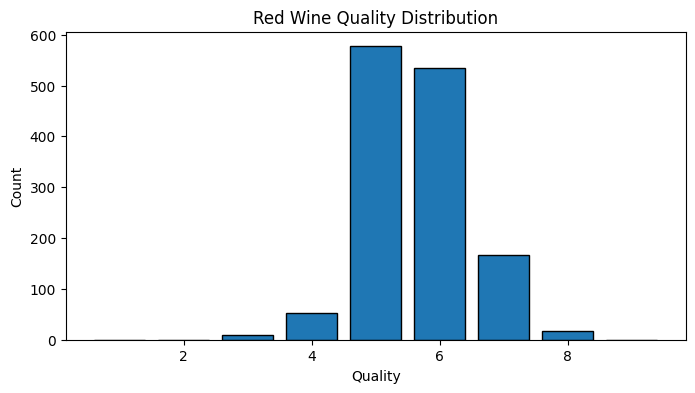

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df_red['quality'], bins=range(1, 11), align='left',
         rwidth=0.8, edgecolor='black')
plt.title('Red Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

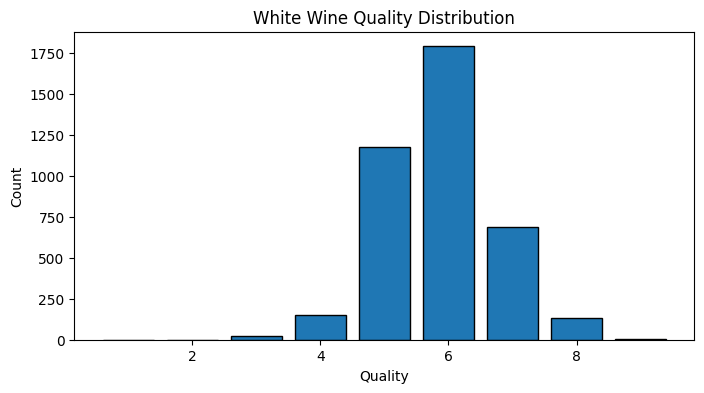

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df_white['quality'], bins=range(1, 11), align='left',
         rwidth=0.8, edgecolor='black')
plt.title('White Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

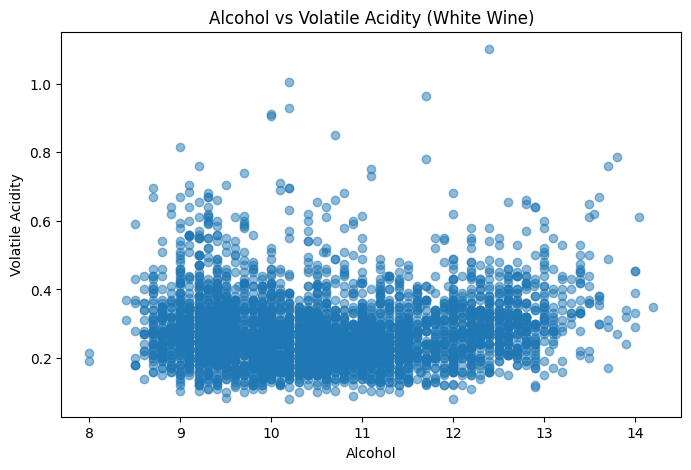

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df_white['alcohol'], df_white['volatile acidity'], alpha=0.5)
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('Alcohol vs Volatile Acidity (White Wine)')
plt.show()

In [16]:
scaler_red = StandardScaler()
Xr_train_scaled = scaler_red.fit_transform(Xr_train)
Xr_test_scaled = scaler_red.transform(Xr_test)

scaler_white = StandardScaler()
Xw_train_scaled = scaler_white.fit_transform(Xw_train)
Xw_test_scaled = scaler_white.transform(Xw_test)

In [17]:
def train_evaluate(X_train, X_test, y_train, y_test, title):
    model = LogisticRegression(max_iter=1000, random_state=62)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{title} Accuracy:", acc)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix – {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

White Wine (Scaled) Accuracy: 0.5258511979823455


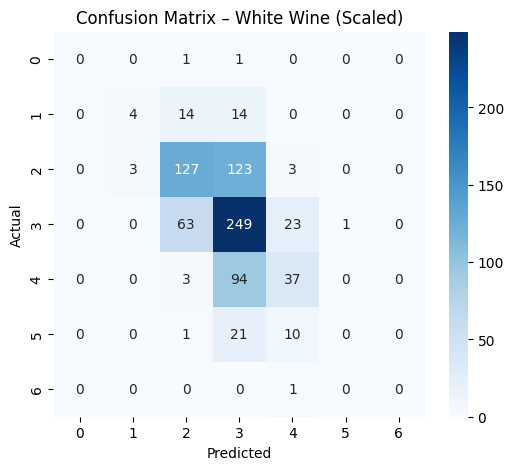

Red Wine (Scaled) Accuracy: 0.5625


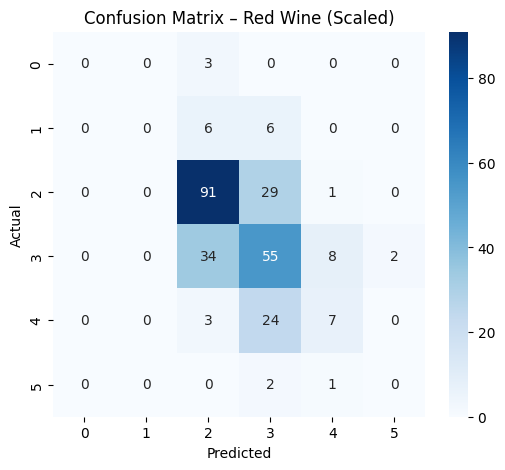

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Red Wine (Unscaled) Accuracy: 0.5808823529411765


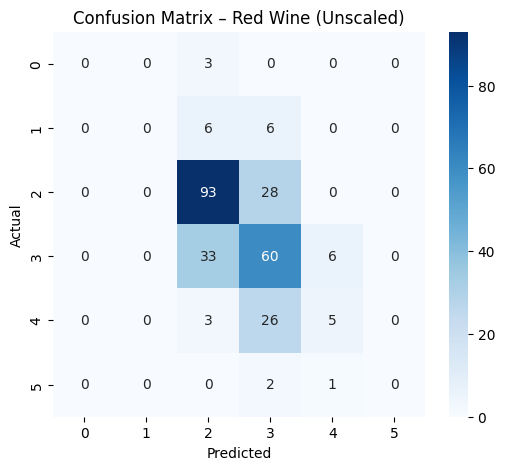

In [18]:
train_evaluate(Xw_train_scaled, Xw_test_scaled, yw_train, yw_test,
               "White Wine (Scaled)")

# Red Wine (Scaled)
train_evaluate(Xr_train_scaled, Xr_test_scaled, yr_train, yr_test,
               "Red Wine (Scaled)")

# Red Wine (Unscaled)
train_evaluate(Xr_train, Xr_test, yr_train, yr_test,
               "Red Wine (Unscaled)")